# Análisis Estratégico de Ventas
## 1. Introducción y Objetivo


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Cargar dataset
file_path = r'c:\Users\Liss\Desktop\Business_Analytics_Dataset.csv'
df = pd.read_csv(file_path)
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Calcular margen de ganancia por transacción
df['Profit_Margin'] = df['Profit'] / df['Revenue']

print(f"Total Ingresos (Revenue): ${df['Revenue'].sum():,.2f}")
print(f"Total Ganancia (Profit): ${df['Profit'].sum():,.2f}")

# KPIs Estratégicos
avg_margin = df['Profit_Margin'].mean()
avg_ticket = df['Revenue'].mean()
revenue_per_customer = df.groupby('Customer_ID')['Revenue'].sum().mean()

print(f"Margen Promedio: {avg_margin:.2%}")
print(f"Ticket Promedio: ${avg_ticket:,.2f}")
print(f"Revenue Promedio por Cliente: ${revenue_per_customer:,.2f}")


Total Ingresos (Revenue): $11,952,419.48
Total Ganancia (Profit): $4,189,497.68
Margen Promedio: 35.01%
Ticket Promedio: $1,195.24
Revenue Promedio por Cliente: $1,994.06


## 2. Desempeño por Región, Categoría y Segmento

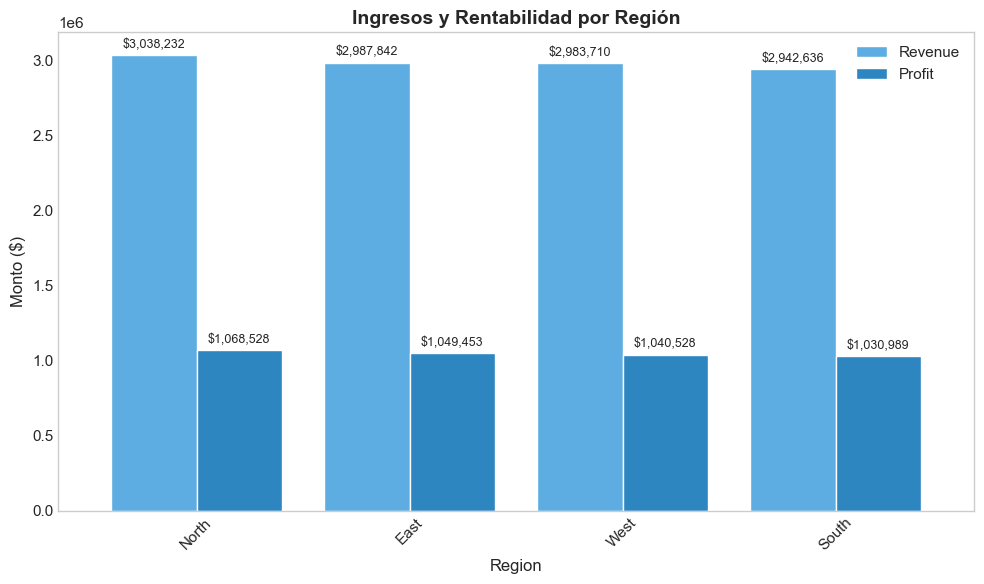

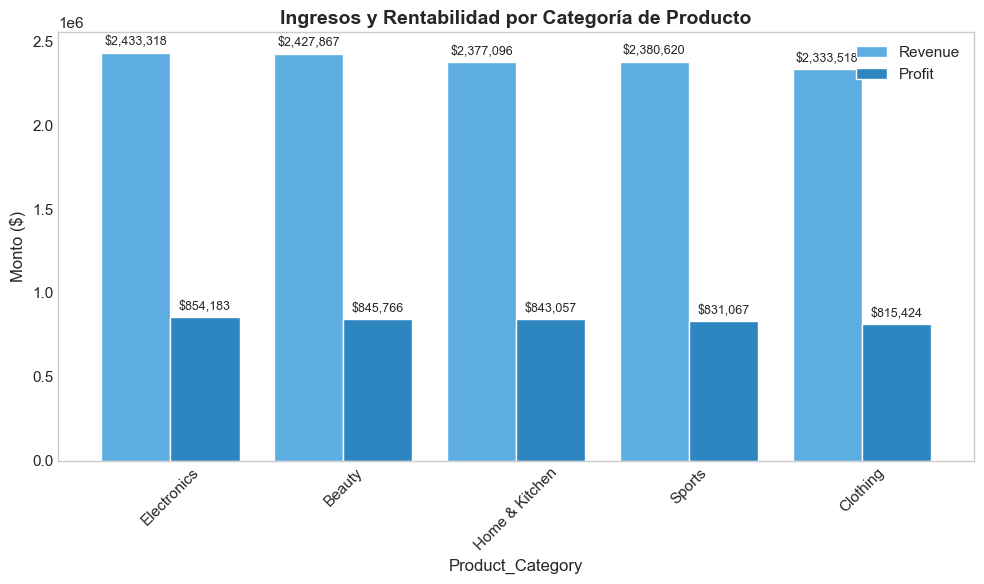

In [47]:
# Función auxiliar para graficar
def plot_revenue_profit(groupby_col, title):
    grouped = df.groupby(groupby_col)[['Revenue', 'Profit']].sum().sort_values(by='Profit', ascending=False)
    fig, ax1 = plt.subplots(figsize=(10, 6))
    grouped.plot(kind='bar', ax=ax1, color=['#5DADE2', '#2E86C1'], width=0.8)
    ax1.grid(False)
    ax1.set_title(title, fontsize=14, fontweight='bold')
    ax1.set_ylabel('Monto ($)')
    ax1.set_xlabel(groupby_col)
    
    for container in ax1.containers:
        ax1.bar_label(container, 
                      fmt='${:,.0f}', 
                      padding=3, 
                      fontsize=9)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 2.1 Por Región
plot_revenue_profit('Region', 'Ingresos y Rentabilidad por Región')

# 2.2 Por Categoría de Producto
plot_revenue_profit('Product_Category', 'Ingresos y Rentabilidad por Categoría de Producto')


**Hallazgos Clave:**
*El análisis refleja una estructura de ingresos sumamente equilibrada, donde la región North y la categoría de Electronics se consolidan como los principales motores de liquidez, alcanzando niveles de profit superiores al millón de dólares. A pesar de la alta competitividad en el sector de Clothing, su menor margen de ganancia en comparación con Beauty sugiere una oportunidad crítica para optimizar la cadena de suministro o renegociar costos fijos, permitiendo así que todas las unidades de negocio converjan hacia el benchmark de rentabilidad del 35% observado en el resto del portafolio.*


## 3. Impacto de los Descuentos en la Rentabilidad

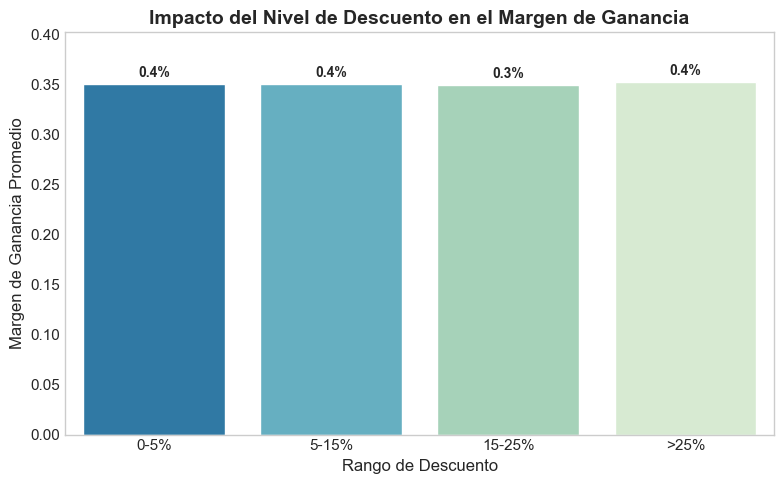

In [ ]:
# Agrupar por niveles de descuento
def plot_discount_impact(df):
    df['Discount_Bin'] = pd.cut(df['Discount_Rate'], bins=[-1, 0.05, 0.15, 0.25, 1], labels=['0-5%', '5-15%', '15-25%', '>25%'])
    discount_impact = df.groupby('Discount_Bin', observed=True)[['Profit_Margin']].mean().reset_index()
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=discount_impact, x='Discount_Bin', y='Profit_Margin', palette='GnBu_r')
    ax.grid(False)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10, fontweight='bold')

    plt.title('Impacto del Nivel de Descuento en el Margen de Ganancia', fontsize=14, fontweight='bold')
    plt.xlabel('Rango de Descuento')
    plt.ylabel('Margen de Ganancia Promedio')
    plt.ylim(0, discount_impact['Profit_Margin'].max() + 0.05)
    plt.tight_layout()
    plt.show()

plot_discount_impact(df)

**Hallazgos Clave:**
*La rentabilidad se mantiene sólida y constante en un 35%, independientemente del nivel de descuento aplicado. Esto confirma que la arquitectura de costos está correctamente blindada, permitiendo campañas de captación agresivas sin comprometer la utilidad unitaria del negocio.*

## 4. Patrones Temporales en Ventas y Profit

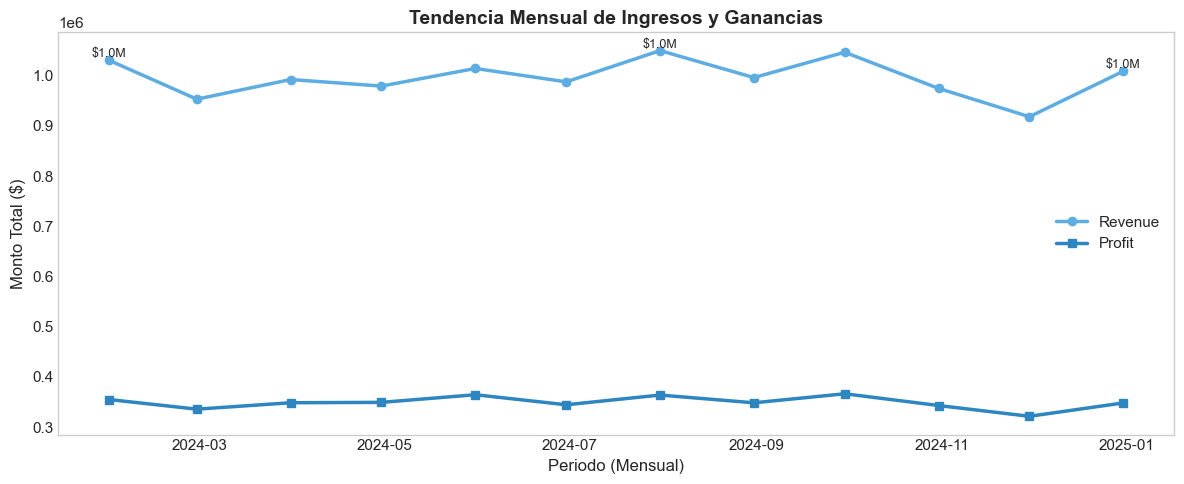

In [63]:
# Tendencia Mensual
monthly_trend = df.resample('M', on='Order_Date')[['Revenue', 'Profit']].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_trend.index, monthly_trend['Revenue'], marker='o', label='Revenue', color='#5DADE2', linewidth=2.5)
plt.plot(monthly_trend.index, monthly_trend['Profit'], marker='s', label='Profit', color='#2E86C1', linewidth=2.5)
plt.title('Tendencia Mensual de Ingresos y Ganancias', fontsize=14, fontweight='bold')
plt.xlabel('Periodo (Mensual)')
plt.ylabel('Monto Total ($)')
plt.grid(False) 
for i, val in enumerate(monthly_trend['Revenue']):
    if i == 0 or i == len(monthly_trend)-1 or val == monthly_trend['Revenue'].max():
        plt.text(monthly_trend.index[i], val, f'${val/1e6:.1f}M', fontsize=9, va='bottom', ha='center')

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

**Hallazgos Clave:**
*El negocio demuestra una estabilidad impresionante, con ventas y ganancias que crecen de la mano mes a mes*

## 5. Segmentación de Clientes: Alto y Bajo Valor

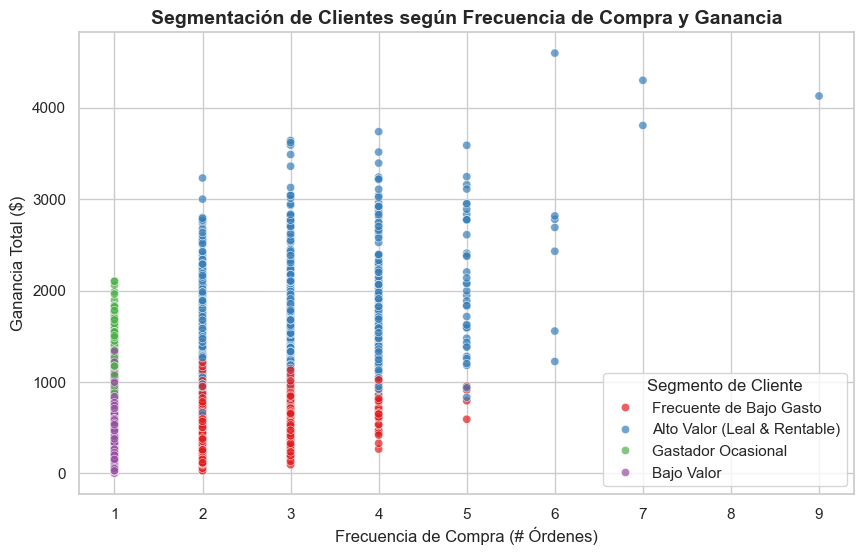

In [13]:
# Calcular métricas por cliente
customer_stats = df.groupby('Customer_ID').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Frequency=('Order_ID', 'count')
).reset_index()

# Definir umbrales (percentil 75 para considerar Alto Valor)
revenue_threshold = customer_stats['Total_Revenue'].quantile(0.75)
frequency_threshold = customer_stats['Frequency'].quantile(0.75)

def segment_customer(row):
    if row['Total_Revenue'] >= revenue_threshold and row['Frequency'] >= frequency_threshold:
        return 'Alto Valor (Leal & Rentable)'
    elif row['Total_Revenue'] >= revenue_threshold:
        return 'Gastador Ocasional'
    elif row['Frequency'] >= frequency_threshold:
        return 'Frecuente de Bajo Gasto'
    else:
        return 'Bajo Valor'

customer_stats['Segment'] = customer_stats.apply(segment_customer, axis=1)

# Visualización de la segmentación
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_stats, x='Frequency', y='Total_Profit', hue='Segment', palette='Set1', alpha=0.7)
plt.title('Segmentación de Clientes según Frecuencia de Compra y Ganancia', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia de Compra (# Órdenes)')
plt.ylabel('Ganancia Total ($)')
plt.legend(title='Segmento de Cliente')
plt.show()

# Resumen numérico por segmento
segment_summary = customer_stats['Segment'].value_counts().reset_index()
segment_summary.columns = ['Segmento', 'Cantidad de Clientes']


## 6. Recomendaciones Ejecutivas

Basado en este análisis estratégico, se realizan las siguientes recomendaciones gerenciales:

1. **Flexibilidad Promocional:** Dado que el margen de ganancia es inelástico (se mantiene en 35%) frente a los descuentos, la empresa tiene margen de maniobra para aplicar rebajas agresivas (>25%) para ganar cuota de mercado o liquidar inventario sin erosionar la rentabilidad unitaria.
2. **Foco en Categorías Top:** Impulsar campañas de retargeting y asegurar el stock preferencial para *Electronics* y *Beauty*, siendo estas las iteraciones con mayor captación de rentabilidad relativa y absoluta.
3. **Gestión Comercial de Clientes:** Implementar programas de fidelidad premium dirigidos exclusivamente a retener el segmento **Alto Valor (Leal & Rentable)**. A su vez, para los clientes **Frecuente de Bajo Gasto**, idear estrategias algorítmicas de *upselling* en el carrito de compras para aumentar el valor promedio del ticket.
